# Zomato Restaurant Data Analysis

## Problem Statement
The objective of this project is to analyze the Zomato restaurant dataset to understand the factors affecting restaurant ratings and customer engagement.

We aim to answer the following questions:

- Do restaurants with online ordering receive more votes?
- Does approximate cost influence restaurant popularity?
- Do table booking options affect ratings?
- Which restaurant type receives higher engagement?

This analysis helps identify key factors that contribute to high restaurant ratings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns',None)

os.chdir(r'G:\$UBH@J!T\Data Analytics\New Data')
zo=pd.read_csv('Zomato-data-.csv')
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


### Show missing values

In [2]:
zo.isnull().mean()

name                           0.0
online_order                   0.0
book_table                     0.0
rate                           0.0
votes                          0.0
approx_cost(for two people)    0.0
listed_in(type)                0.0
dtype: float64

### Show duplicate values

In [3]:
zo.loc[zo.duplicated()==True,]

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)


In [4]:
zo.dtypes

name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
approx_cost(for two people)     int64
listed_in(type)                object
dtype: object

##  Rating-Based Analysis (Quality Analysis)

### Show which restaurants have the highest ratings.

In [4]:
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [5]:
zo['rate'] = zo['rate'].str.split('/').str[0]
zo['rate'] = pd.to_numeric(zo['rate'], errors='coerce')
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


## Note: Onesta has the highest rating in the dataset, 
## and Empire Restaurant as the second-highest rated restaurant.

## Show Which restaurant type (Buffet, Cafe, Casual Dining, etc.) 
# has the highest average rating?

In [6]:
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [7]:
highest_rate=zo.sort_values(by='rate',ascending=0)
highest_rate[['name','rate']].head(10)

,name,rate
44,Onesta,4.6
7,Onesta,4.6
38,Empire Restaurant,4.4
86,Meghana Foods,4.4
52,Corner House Ice Cream,4.3
37,Szechuan Dragon,4.2
60,Peppy Peppers,4.2
81,Frozen Bottle,4.2
12,The Coffee Shack,4.2
11,Cafe Shuffle,4.2


In [8]:
highest_avg_rating = pd.pivot_table(data=zo,index='listed_in(type)',values='rate',aggfunc=['mean'])
highest_avg_rating

,mean
,rate
listed_in(type),
Buffet,3.842857
Cafes,3.765217
Dining,3.571818
other,3.912500


## Note : as we see the others catagory has the highest avg rate

## 	Does higher cost lead to higher rating?

In [9]:
Cost_catagory=zo[['rate','approx_cost(for two people)']].corr()
Cost_catagory

,rate,approx_cost(for two people)
rate,1.000000,0.275216
approx_cost(for two people),0.275216,1.000000


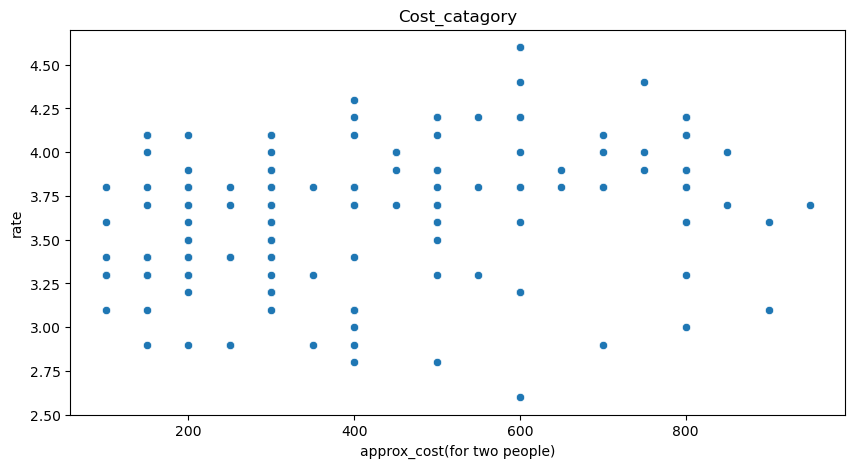

In [10]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=zo,x='approx_cost(for two people)',y='rate')
plt.title('Cost_catagory')
plt.show()

## Note : we see that the restaurant with the highest rating has an approximate cost(for two people) of ₹600.

## Do restaurants with online ordering have better ratings ?

In [11]:
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [12]:
Online_order_rating= pd.pivot_table(data=zo, index='online_order', values='rate', aggfunc='mean')
Online_order_rating

,rate
online_order,
No,3.487778
Yes,3.858621


## Note : We can observe that restaurants offering online ordering (‘Yes’) have slightly higher average ratings compared to those that do not offer online ordering (‘No’)

## 	Do restaurants with table booking have better ratings ?

In [13]:
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [14]:
Rate_of_table_book= pd.pivot_table(data=zo, index='book_table', values= 'rate', aggfunc='mean')
Rate_of_table_book

,rate
book_table,
No,3.601429
Yes,4.187500


## Note : Here we can see table book (yes) rating is better then table book (no).

## 	Are high-rated restaurants also highly voted?

In [15]:
zo.head()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [16]:
rating_votes=pd.pivot_table(data=zo, index= 'rate', values= 'votes', aggfunc= 'mean')
rating_votes

,votes
rate,
2.6,283.000000
2.8,298.500000
2.9,15.571429
3.0,80.000000
3.1,46.142857
3.2,16.428571
3.3,8.642857
3.4,1.333333
3.5,21.166667


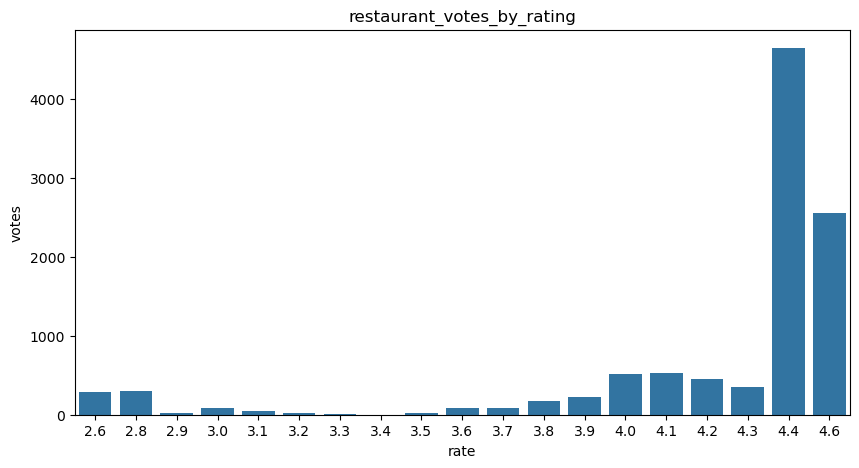

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(data=rating_votes, x='rate', y='votes')
plt.title('restaurant_votes_by_rating')
plt.show()

## Note :  We can observe that restaurants with a rating of 4.4 out of 5 receive the highest number of votes. 
# So yes are highly rated restaurants also highly vote.

##  Factors of Increase Votes?

## Which restaurants have the highest votes?

In [18]:
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [19]:
vote_of_restrurents= zo.groupby('name')['votes'].sum().sort_values(ascending=0)
vote_of_restrurents.head(10)

name
Onesta                5112
Empire Restaurant     4884
Meghana Foods         4401
San Churro Cafe       1836
Kabab Magic           1720
Szechuan Dragon       1647
Roving Feast          1047
Gustoes Beer House     868
Jeet Restaurant        808
Recipe                 804
Name: votes, dtype: int64

## Note :  Here we can see top 10 vote_of_restrurents

## What factors increase votes?

In [20]:
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [21]:
online_order_wise_vote=zo.groupby('online_order')['votes'].mean().sort_values(ascending=0)
online_order_wise_vote

online_order
Yes    559.000000
No      75.222222
Name: votes, dtype: float64

## Note : Restaurants offering online ordering receive higher average votes compared to those that do not.

In [22]:
book_table_wise_votes=zo.groupby('book_table')['votes'].mean().sort_values(ascending=0)
book_table_wise_votes

book_table
Yes    940.750000
No     226.185714
Name: votes, dtype: float64

## Note : We can observe that the number of votes increases for restaurants that offer table booking

In [23]:
zo[['approx_cost(for two people)','votes']].corr()

,approx_cost(for two people),votes
approx_cost(for two people),1.000000,0.324372
votes,0.324372,1.000000


## Note :  We observe a moderate positive relationship between cost and votes, meaning restaurants with higher pricing generally receive more votes.

In [24]:
votes_by_listed_in_type = zo.groupby('listed_in(type)')['votes'].mean().sort_values(ascending=0)
votes_by_listed_in_type

listed_in(type)
other     1170.875000
Buffet     432.571429
Cafes      279.739130
Dining     185.118182
Name: votes, dtype: float64

## Note : Here we observe that the number of votes increases for restaurants in certain listed_in(type) categories.

## Does online_order affect votes?

In [26]:
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [27]:
vote_based_by_online_order= pd.pivot_table(data=zo,index='online_order',values='votes',aggfunc='mean')
vote_based_by_online_order

,votes
online_order,
No,75.222222
Yes,559.000000


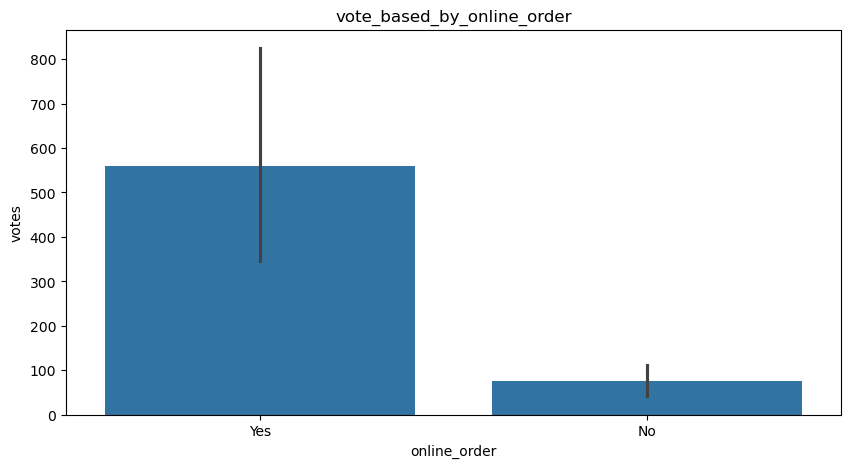

In [28]:
plt.figure(figsize=(10,5))
sns.barplot(data=zo, x='online_order', y='votes')
plt.title('vote_based_by_online_order')
plt.show()

## Note : We can see (Yes) online order is effect the votes

## Does book_table increase votes?

In [29]:
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [30]:
vote_based_by_book_table= pd.pivot_table(data=zo, index='book_table', values='votes', aggfunc='mean')
vote_based_by_book_table

,votes
book_table,
No,226.185714
Yes,940.750000


## Note : We can see (Yes) book_table is effect the votes

## Predictive Insight

In [31]:
zo.dtypes

name                            object
online_order                    object
book_table                      object
rate                           float64
votes                            int64
approx_cost(for two people)      int64
listed_in(type)                 object
dtype: object

In [32]:
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [27]:
len(zo)

148

## Creat feature engineering

In [33]:
zo['High_rating']=np.where(zo['rate']>=4,1,0)
zo.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),High_rating
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,1
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,1
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,0
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,0
4,Grand Village,No,No,3.8,166,600,Buffet,0


## drop name column

In [34]:
zo=zo.drop(['name','rate'],axis=1)
zo.head(2)

,online_order,book_table,votes,approx_cost(for two people),listed_in(type),High_rating
0,Yes,Yes,775,800,Buffet,1
1,Yes,No,787,800,Buffet,1


## Change column name

In [35]:
zo=zo.rename(columns={'listed_in(type)':'listed_type'})
zo.head()

,online_order,book_table,votes,approx_cost(for two people),listed_type,High_rating
0,Yes,Yes,775,800,Buffet,1
1,Yes,No,787,800,Buffet,1
2,Yes,No,918,800,Buffet,0
3,No,No,88,300,Buffet,0
4,No,No,166,600,Buffet,0


## Creat dummies

In [36]:
zo=pd.get_dummies(data=zo,columns=['online_order','book_table','listed_type'],drop_first=True)
zo.head()

,votes,approx_cost(for two people),High_rating,online_order_Yes,book_table_Yes,listed_type_Cafes,listed_type_Dining,listed_type_other
0,775,800,1,True,True,False,False,False
1,787,800,1,True,False,False,False,False
2,918,800,0,True,False,False,False,False
3,88,300,0,False,False,False,False,False
4,166,600,0,False,False,False,False,False


## find Outliers usnig Boxplot 

In [37]:
def outlier (data,age):
 Q1 = data[age].quantile(0.25)
 Q3 = data[age].quantile(0.75)
 IQR = Q3 - Q1
 data= data.loc[~((data[age] < (Q1 - 1.5 * IQR)) | (data[age] > (Q3 + 1.5 * IQR))),]
 return data

In [38]:
zo.columns


Index(['votes', 'approx_cost(for two people)', 'High_rating',
       'online_order_Yes', 'book_table_Yes', 'listed_type_Cafes',
       'listed_type_Dining', 'listed_type_other'],
      dtype='object')

<Axes: >

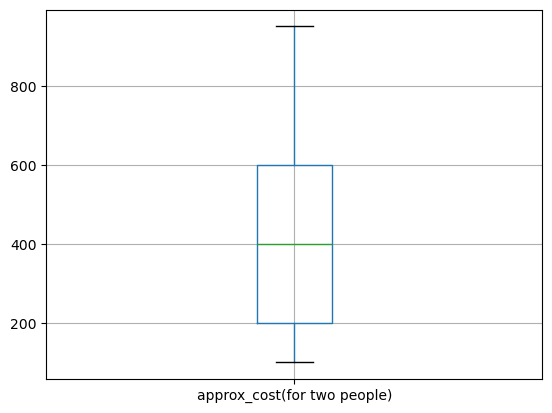

In [39]:
zo.boxplot(column=['approx_cost(for two people)'])

<Axes: >

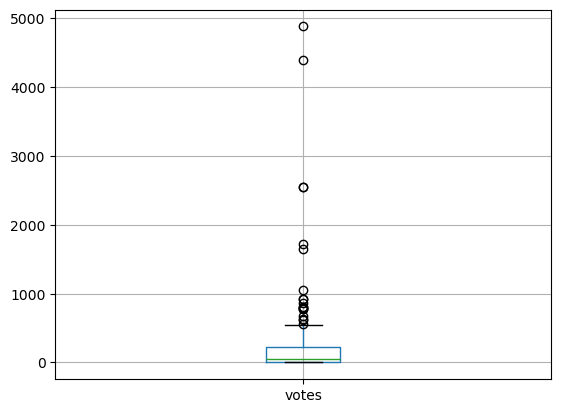

In [40]:
zo.boxplot(column=['votes'])

In [41]:
zo=outlier(zo,'votes')
zo.head()

,votes,approx_cost(for two people),High_rating,online_order_Yes,book_table_Yes,listed_type_Cafes,listed_type_Dining,listed_type_other
3,88,300,0,False,False,False,False,False
4,166,600,0,False,False,False,False,False
5,286,600,0,True,False,False,False,False
6,8,800,0,False,False,False,False,False
8,324,700,1,True,False,False,False,True


<Axes: >

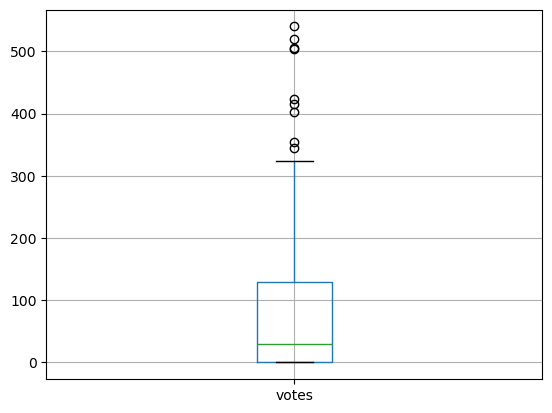

In [42]:
zo.boxplot(column=['votes'])

In [43]:
zo.head()

,votes,approx_cost(for two people),High_rating,online_order_Yes,book_table_Yes,listed_type_Cafes,listed_type_Dining,listed_type_other
3,88,300,0,False,False,False,False,False
4,166,600,0,False,False,False,False,False
5,286,600,0,True,False,False,False,False
6,8,800,0,False,False,False,False,False
8,324,700,1,True,False,False,False,True


## Creat Ml models by using Logistic Regration

In [44]:
import statsmodels.formula.api as sm
import statsmodels.api as sm

## Show Correlation

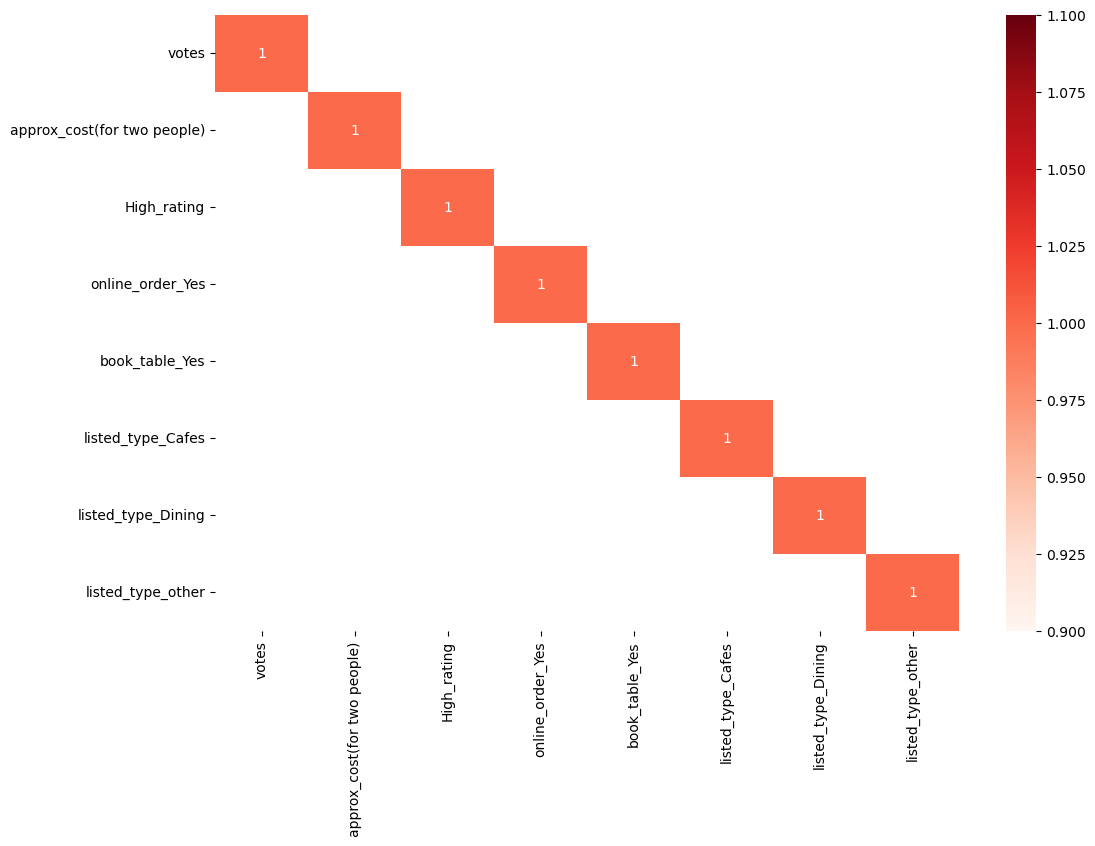

In [45]:
import numpy as np

corr = zo.corr()

plt.figure(figsize=(12,8))

mask = np.abs(corr) < 0.8   # hide weak correlations

sns.heatmap(corr, 
            mask=mask, 
            cmap="Reds", 
            annot=True)

plt.show()            

In [46]:
inputdata=zo.drop('High_rating',axis=1)
inputdata.head()

,votes,approx_cost(for two people),online_order_Yes,book_table_Yes,listed_type_Cafes,listed_type_Dining,listed_type_other
3,88,300,False,False,False,False,False
4,166,600,False,False,False,False,False
5,286,600,True,False,False,False,False
6,8,800,False,False,False,False,False
8,324,700,True,False,False,False,True


In [47]:
outputdata=zo.loc[:,'High_rating']
outputdata.head()

3    0
4    0
5    0
6    0
8    1
Name: High_rating, dtype: int32

In [48]:
inputdata=inputdata.astype(float)
inputdata.head()

,votes,approx_cost(for two people),online_order_Yes,book_table_Yes,listed_type_Cafes,listed_type_Dining,listed_type_other
3,88.0,300.0,0.0,0.0,0.0,0.0,0.0
4,166.0,600.0,0.0,0.0,0.0,0.0,0.0
5,286.0,600.0,1.0,0.0,0.0,0.0,0.0
6,8.0,800.0,0.0,0.0,0.0,0.0,0.0
8,324.0,700.0,1.0,0.0,0.0,0.0,1.0


In [49]:
outputdata=outputdata.astype(float)
outputdata

3      0.0
4      0.0
5      0.0
6      0.0
8      1.0
      ... 
142    0.0
143    0.0
144    0.0
146    0.0
147    0.0
Name: High_rating, Length: 129, dtype: float64

In [50]:
logit=sm.Logit(outputdata,inputdata)
result=logit.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.275868
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            High_rating   No. Observations:                  129
Model:                          Logit   Df Residuals:                      122
Method:                           MLE   Df Model:                            6
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                  0.3400
Time:                        19:57:11   Log-Likelihood:                -35.587
converged:                       True   LL-Null:                       -53.919
Covariance Type:            nonrobust   LLR p-value:                 2.048e-06
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
votes                           0.0096      0.003      3.475      0.001       0.004       0.015
approx_cost(for two people)    -0.0066      0.002     -3.023      0.003      -0.011      -0.002
online_order_Yes                0.4232      0.700      0.605      0.545      -0.949       1.795
book_table_Yes                  3.6737      1.714      2.144      0.032       0.315       7.032
listed_type_Cafes              -0.0059      1.024     -0.006      0.995      -2.014       2.002
listed_type_Dining             -1.3776      0.616     -2.237      0.025      -2.584      -0.171
listed_type_other               1.8932      1.781      1.063      0.288      -1.597       5.384
===============================================================================================
"""

## as we see listed_type_other p-value higher then 0.05 so we need to remove that  

In [53]:
inputdata=zo.loc[:,['votes', 'approx_cost(for two people)',
       'online_order_Yes', 'book_table_Yes', 'listed_type_Cafes',
       'listed_type_Dining']]
inputdata.head()

,votes,approx_cost(for two people),online_order_Yes,book_table_Yes,listed_type_Cafes,listed_type_Dining
3,88,300,False,False,False,False
4,166,600,False,False,False,False
5,286,600,True,False,False,False
6,8,800,False,False,False,False
8,324,700,True,False,False,False


In [54]:
inputdata=inputdata.astype(float)
inputdata.head()

,votes,approx_cost(for two people),online_order_Yes,book_table_Yes,listed_type_Cafes,listed_type_Dining
3,88.0,300.0,0.0,0.0,0.0,0.0
4,166.0,600.0,0.0,0.0,0.0,0.0
5,286.0,600.0,1.0,0.0,0.0,0.0
6,8.0,800.0,0.0,0.0,0.0,0.0
8,324.0,700.0,1.0,0.0,0.0,0.0


In [55]:
outputdata=zo.loc[:,'High_rating']
outputdata.head()

3    0
4    0
5    0
6    0
8    1
Name: High_rating, dtype: int32

In [56]:
logit=sm.Logit(outputdata,inputdata)
result=logit.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.280596
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            High_rating   No. Observations:                  129
Model:                          Logit   Df Residuals:                      123
Method:                           MLE   Df Model:                            5
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                  0.3287
Time:                        19:57:55   Log-Likelihood:                -36.197
converged:                       True   LL-Null:                       -53.919
Covariance Type:            nonrobust   LLR p-value:                 1.227e-06
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
votes                           0.0095      0.003      3.604      0.000       0.004       0.015
approx_cost(for two people)    -0.0054      0.002     -3.051      0.002      -0.009      -0.002
online_order_Yes                0.4367      0.699      0.624      0.532      -0.934       1.808
book_table_Yes                  3.3757      1.546      2.183      0.029       0.345       6.406
listed_type_Cafes              -0.5345      0.878     -0.609      0.542      -2.254       1.185
listed_type_Dining             -1.7196      0.532     -3.233      0.001      -2.762      -0.677
===============================================================================================
"""

## as we see listed_type_other p-value higher then 0.05 so we need to remove that  

In [57]:
inputdata=zo.loc[:,['votes', 'approx_cost(for two people)',
        'book_table_Yes', 'listed_type_Cafes',
       'listed_type_Dining']]
inputdata.head()

,votes,approx_cost(for two people),book_table_Yes,listed_type_Cafes,listed_type_Dining
3,88,300,False,False,False
4,166,600,False,False,False
5,286,600,False,False,False
6,8,800,False,False,False
8,324,700,False,False,False


In [58]:
inputdata=inputdata.astype(float)
inputdata.head()

,votes,approx_cost(for two people),book_table_Yes,listed_type_Cafes,listed_type_Dining
3,88.0,300.0,0.0,0.0,0.0
4,166.0,600.0,0.0,0.0,0.0
5,286.0,600.0,0.0,0.0,0.0
6,8.0,800.0,0.0,0.0,0.0
8,324.0,700.0,0.0,0.0,0.0


In [59]:
outputdata=zo.loc[:,'High_rating']
outputdata.head()

3    0
4    0
5    0
6    0
8    1
Name: High_rating, dtype: int32

In [60]:
logit=sm.Logit(outputdata,inputdata)
result=logit.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.282077
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            High_rating   No. Observations:                  129
Model:                          Logit   Df Residuals:                      124
Method:                           MLE   Df Model:                            4
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                  0.3251
Time:                        19:58:15   Log-Likelihood:                -36.388
converged:                       True   LL-Null:                       -53.919
Covariance Type:            nonrobust   LLR p-value:                 4.512e-07
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
votes                           0.0099      0.003      3.813      0.000       0.005       0.015
approx_cost(for two people)    -0.0052      0.002     -3.043      0.002      -0.008      -0.002
book_table_Yes                  3.5159      1.531      2.296      0.022       0.515       6.517
listed_type_Cafes              -0.4240      0.857     -0.495      0.621      -2.104       1.256
listed_type_Dining             -1.6714      0.520     -3.211      0.001      -2.691      -0.651
===============================================================================================
"""

## as we see listed_type_Cafes p-value higher then 0.05 so we need to remove that 

In [61]:
inputdata=zo.loc[:,['votes', 'approx_cost(for two people)',
        'book_table_Yes', 
       'listed_type_Dining']]
inputdata.head()

,votes,approx_cost(for two people),book_table_Yes,listed_type_Dining
3,88,300,False,False
4,166,600,False,False
5,286,600,False,False
6,8,800,False,False
8,324,700,False,False


In [62]:
inputdata=inputdata.astype(float)
inputdata.head()

,votes,approx_cost(for two people),book_table_Yes,listed_type_Dining
3,88.0,300.0,0.0,0.0
4,166.0,600.0,0.0,0.0
5,286.0,600.0,0.0,0.0
6,8.0,800.0,0.0,0.0
8,324.0,700.0,0.0,0.0


In [63]:
outputdata=zo.loc[:,'High_rating']
outputdata.head()

3    0
4    0
5    0
6    0
8    1
Name: High_rating, dtype: int32

In [66]:
logit=sm.Logit(outputdata,inputdata)
result=logit.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.283027
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            High_rating   No. Observations:                  129
Model:                          Logit   Df Residuals:                      125
Method:                           MLE   Df Model:                            3
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                  0.3229
Time:                        20:00:41   Log-Likelihood:                -36.510
converged:                       True   LL-Null:                       -53.919
Covariance Type:            nonrobust   LLR p-value:                 1.332e-07
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
votes                           0.0101      0.003      3.844      0.000       0.005       0.015
approx_cost(for two people)    -0.0056      0.001     -3.763      0.000      -0.008      -0.003
book_table_Yes                  3.5501      1.585      2.240      0.025       0.444       6.656
listed_type_Dining             -1.5597      0.469     -3.326      0.001      -2.479      -0.640
===============================================================================================
"""

In [67]:
var = pd.DataFrame(round(result.pvalues,3))# shows p value
var["coeff"] = result.params#coefficients
#rename columns
var.columns.values[[0,1]]= ["p value","coefficients"]
var

,p value,coefficients
votes,0.000,0.010073
approx_cost(for two people),0.000,-0.005587
book_table_Yes,0.025,3.550133
listed_type_Dining,0.001,-1.559680


In [68]:
cov = result.cov_params()
std_err = np.sqrt(np.diag(cov))
var["z"]=result.params.values/std_err
var
# end of may not run this code

result.conf_int()# confidence interval

np.exp(result.params)#odds ratio (may igmore it for the time being)


votes                           1.010124
approx_cost(for two people)     0.994428
book_table_Yes                 34.817958
listed_type_Dining              0.210203
dtype: float64

### VIF Calculation

In [69]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [70]:
zo=zo.rename(columns={'approx_cost(for two people)':'approx_cost_two'})
zo.head()

,votes,approx_cost_two,High_rating,online_order_Yes,book_table_Yes,listed_type_Cafes,listed_type_Dining,listed_type_other
3,88,300,0,False,False,False,False,False
4,166,600,0,False,False,False,False,False
5,286,600,0,True,False,False,False,False
6,8,800,0,False,False,False,False,False
8,324,700,1,True,False,False,False,True


In [71]:
result=sm.ols(formula='''High_rating ~ votes + approx_cost_two + 
        book_table_Yes +  
       listed_type_Dining''',data=zo).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            High_rating   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     15.30
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           3.38e-10
Time:                        20:00:59   Log-Likelihood:                -23.347
No. Observations:                 129   AIC:                             56.69
Df Residuals:                     124   BIC:                             70.99
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.2331      0.097      2.403      0.018       0.041       0.425
book_table_Yes[T.True]         0.4985      0.156      3.191      0.002       0.189       0.808
listed_type_Dining[T.True]    -0.1106      0.072     -1.542      0.126      -0.252       0.031
votes                          0.0014      0.000      5.848      0.000       0.001       0.002
approx_cost_two               -0.0003      0.000     -2.398      0.018      -0.001    -6.1e-05
==============================================================================
Omnibus:                       46.296   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              102.358
Skew:                           1.498   Prob(JB):                     5.93e-23
Kurtosis:                       6.173   Cond. No.                     2.72e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.72e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [72]:
var = pd.DataFrame(round(result.pvalues,3))# shows p value
var["coeff"] = result.params#coefficients
variables = result.model.exog #.if I had saved data as rock
# this it would have looked like rock.model.exog
vif = [variance_inflation_factor(variables, i) for i in range(variables.shape[1])]
vif 
var["vif"] = vif
var

,0,coeff,vif
Intercept,0.018,0.233076,13.872938
book_table_Yes[T.True],0.002,0.498457,1.081189
listed_type_Dining[T.True],0.126,-0.110558,1.383805
votes,0.000,0.001359,1.267212
approx_cost_two,0.018,-0.000350,1.395920


## AUC

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [74]:
inputdata=zo.loc[:,[ 'votes', 'approx_cost_two',
        'book_table_Yes', 
       'listed_type_Dining']]
inputdata.head()

,votes,approx_cost_two,book_table_Yes,listed_type_Dining
3,88,300,False,False
4,166,600,False,False
5,286,600,False,False
6,8,800,False,False
8,324,700,False,False


In [75]:
outputdata=zo.loc[:,'High_rating']
outputdata.head()

3    0
4    0
5    0
6    0
8    1
Name: High_rating, dtype: int32

In [76]:
logit1=LogisticRegression()
logit1.fit(inputdata,outputdata)
logit1.score(inputdata,outputdata)

0.8914728682170543

In [78]:
y_pred = logit1.predict(inputdata)
prob = logit1.predict_proba(inputdata)
#prob.count()
#transform the probabilities into DataFrame
# it shows probability for both
prob = pd.DataFrame(prob)
prob = prob.iloc[:,1]#showing the probability of being 1
prob = prob.reset_index()
prob.head()

,index,1
0,0,0.203138
1,1,0.181260
2,2,0.405516
3,3,0.027355
4,4,0.421402


In [79]:
outputdata = pd.DataFrame(outputdata)
outputdata.head()
outputdata = outputdata.reset_index()
outputdata = outputdata.iloc[:,1]
outputdata.head()

0    0
1    0
2    0
3    0
4    1
Name: High_rating, dtype: int32

In [80]:
rock = pd.concat([outputdata,prob], axis=1)
rock = rock.iloc[:,[0,2]]#this line might give error, check the column index
rock.head()
df = rock.copy()
df.columns = ["y","p"]
df.head()

,y,p
0,0,0.203138
1,0,0.181260
2,0,0.405516
3,0,0.027355
4,1,0.421402


In [81]:
###Confusion matrix with sklearn
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
confusion_matrix(logit1.predict(inputdata),outputdata)# this is experimental not required

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(logit1.predict(inputdata),outputdata))
print(classification_report(logit1.predict(inputdata),outputdata))


[[108  12]
 [  2   7]]
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       120
           1       0.37      0.78      0.50         9

    accuracy                           0.89       129
   macro avg       0.68      0.84      0.72       129
weighted avg       0.94      0.89      0.91       129



In [83]:
zo['High_rating'].value_counts()

High_rating
0    110
1     19
Name: count, dtype: int64

## Check ROC 

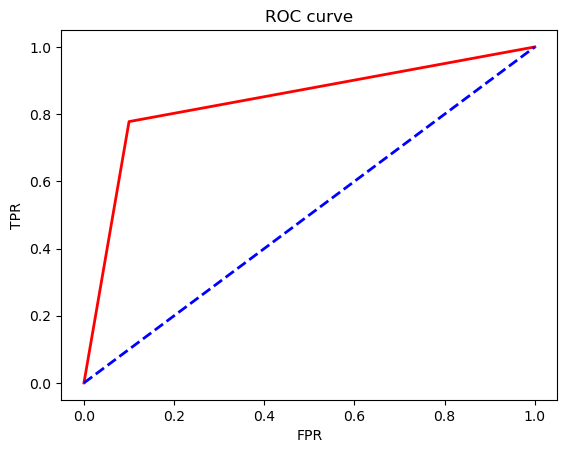

0.8388888888888888

In [84]:
##Computing false and true positive rates
fpr, tpr,_=roc_curve(logit1.predict(inputdata),outputdata,drop_intermediate=False)

import matplotlib.pyplot as plt
plt.figure()
##Adding the ROC
plt.plot(fpr, tpr, color='red',
 lw=2, label='ROC curve')
##Random FPR and TPR
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
##Title and label
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve')
plt.show()
roc_auc_score(logit1.predict(inputdata),outputdata)


## Check KS

In [86]:
df = rock.copy()
df.columns = ["y","p"]
df.head()

new = df.copy()
new.columns = ["Churn","Prob"]
new.head()

new['decile'] = pd.qcut(new['Prob'],10,
labels=['1','2','3','4','5','6','7','8','9','10'])
new.head()

new.columns = ['Defaulter','Probability','Decile']
new.head()
new['Non-Defaulter'] = 1-new['Defaulter']
new.head()


boogieman = pd.pivot_table(data=new,index=['Decile'],
values=['Defaulter','Non-Defaulter','Probability'],
aggfunc={'Defaulter':[np.sum],'Non-Defaulter':[np.sum],
'Probability' : [np.min,np.max]})
boogieman.head()
boogieman.reset_index()

boogieman.columns = ['Defaulter_Count','Non-Defaulter_Count','max_score','min_score']
boogieman['Total_Cust'] = boogieman['Defaulter_Count']+boogieman['Non-Defaulter_Count']
boogieman

kane = boogieman.sort_values(by='min_score',ascending=False)
kane


kane['Default_Rate'] = (kane['Defaulter_Count'] / 
kane['Total_Cust']).apply('{0:.2%}'.format)
default_sum = kane['Defaulter_Count'].sum()
non_default_sum = kane['Non-Defaulter_Count'].sum()
kane['Default %'] = (kane['Defaulter_Count']/
default_sum).apply('{0:.2%}'.format)
kane['Non_Default %'] = (kane['Non-Defaulter_Count']/
non_default_sum).apply('{0:.2%}'.format)
kane

kane['ks_stats'] = np.round(((kane['Defaulter_Count'] / 
kane['Defaulter_Count'].sum()).cumsum() -
(kane['Non-Defaulter_Count'] / 
kane['Non-Defaulter_Count'].sum()).cumsum()), 4) * 100
kane

flag = lambda x: '*****' if x == kane['ks_stats'].max() else ''
kane['max_ks'] = kane['ks_stats'].apply(flag)
kane


C:\Users\kundu\AppData\Local\Temp\ipykernel_11880\2004540491.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  boogieman = pd.pivot_table(data=new,index=['Decile'],
C:\Users\kundu\AppData\Local\Temp\ipykernel_11880\2004540491.py:19: FutureWarning: The provided callable <function sum at 0x00000258ECA2D120> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  boogieman = pd.pivot_table(data=new,index=['Decile'],
C:\Users\kundu\AppData\Local\Temp\ipykernel_11880\2004540491.py:19: FutureWarning: The provided callable <function min at 0x00000258ECA2D940> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mi

,Defaulter_Count,Non-Defaulter_Count,max_score,min_score,Total_Cust,Default_Rate,Default %,Non_Default %,ks_stats,max_ks
Decile,,,,,,,,,,
10,9,4,0.877755,0.405516,13,69.23%,47.37%,3.64%,43.73,
9,4,9,0.396058,0.187270,13,30.77%,21.05%,8.18%,56.60,*****
8,1,12,0.183026,0.108574,13,7.69%,5.26%,10.91%,50.96,
7,2,11,0.104071,0.083253,13,15.38%,10.53%,10.00%,51.48,
6,1,10,0.082397,0.071252,11,9.09%,5.26%,9.09%,47.66,
5,1,13,0.071118,0.066025,14,7.14%,5.26%,11.82%,41.10,
4,1,12,0.065159,0.058109,13,7.69%,5.26%,10.91%,35.45,
3,0,13,0.054143,0.048875,13,0.00%,0.00%,11.82%,23.64,
2,0,13,0.047161,0.035684,13,0.00%,0.00%,11.82%,11.82,
